# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 1. Data Overview & Quality Validation

### Data Loading & Preview

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivo
df = pd.read_csv('landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
print(df.shape)
print(df.info())

(40000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB
None


✍️ **Comentario**:
 - El dataset contiene 40,000 entradas sin valores ausentes.
 - Los tipos de datos son correctos para el análisis, sin valores ausentes y desglosados como se describe a continuación:
  - **Identificador:** `user_id`
  - **Variables categóricas:** `landing`, `region`, `dispositivo`, `traffic_source` y `user_type` clasificadas como `object`.
  - **Variables numéricas:** `gasto` clasificada como `float64`, adecuada para el análisis de gasto y `converted` clasificada como `int64` (0 o 1), adecuado para el análisis de conversión.
 - La columna `date` está clasificada como `object` y podría convertirse a `datetime`, pero no es necesario para los análisis planteados.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### Exploratory Data Quality Review

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print(df['user_id'].nunique())

40000


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
print(df['converted'].value_counts())

0    34294
1     5706
Name: converted, dtype: int64


In [10]:
# Resumen estadístico de usuarios que se convirtieron en porcentaje
print(df['converted'].value_counts(normalize=True).round(4) * 100)

0    85.74
1    14.26
Name: converted, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
columnas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
for col in columnas:
    print(f"\n{col}:")
    print(df[col].value_counts())


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**: 
- El dataset contiene 40,000 usuarios únicos, sin registros duplicados.
- El experimento se llevó a cabo durante enero de 2026, con una duración de 28 días.
- El gasto presenta un rango de $0 a $303.68. El 75% de los usuarios no realizó 
  ninguna compra, lo que genera una distribución sesgada donde la media ($9.33) 
  no refleja el comportamiento típico del usuario.
- Solo el 14.26% de los usuarios convirtieron (5,706 de 40,000), 
  lo que indica una tasa de conversión baja pero esperable en este tipo de experimentos.
- Los grupos del experimento están balanceados: grupo A con 19,982 usuarios 
  y grupo B con 20,018, lo que garantiza comparaciones válidas entre ambas versiones.
- La región Norte concentra el mayor volumen de tráfico (11,166 usuarios), 
  seguida por Centro y Sur.
- El dispositivo predominante es Mobile (24,829 usuarios), representando 
  el 62% del tráfico total.
- La fuente de tráfico principal es Organic (17,987 usuarios), 
  seguida por Ads y Email.
- Los usuarios nuevos representan la mayoría del tráfico 
  (26,033 vs 13,967 recurrentes).

## 💰 2. Average Spend Comparison — Page A vs B

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A')& (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)] ['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [33]:
# Gasto promedio por grupo (usuarios que convirtieron)
print(f"Gasto promedio Página A: ${gasto_A.mean():.2f}")
print(f"Gasto promedio Página B: ${gasto_B.mean():.2f}")
print(f"Diferencia: ${gasto_B.mean() - gasto_A.mean():.2f}")

Gasto promedio Página A: $61.09
Gasto promedio Página B: $68.75
Diferencia: $7.66


### Mann-Whitney U Test


**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de usuarios que convirtieron en la página A es igual al de la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de usuarios que convirtieron en la página A es diferente al de la página B.


In [13]:
# Aplicar prueba
u_stats, p_value = stats.mannwhitneyu(gasto_A, gasto_B, alternative='two-sided')
# Visualizar resultados
print(f"Estadístico U: {u_stats}")
print(f"Valor p: {p_value}")

Estadístico U: 3420354.0
Valor p: 1.0437550649433317e-21


In [14]:
n_A = len(gasto_A)
n_B = len(gasto_B)

u_max = n_A * n_B
u_mitad = u_max / 2

print("Total de duelos posibles:", u_max)
print("Mitad:", u_mitad)
print("U de A:", u_stats)
print("U de B:", u_max - u_stats)

Total de duelos posibles: 8023328
Mitad: 4011664.0
U de A: 3420354.0
U de B: 4602974.0


### 📝 Conclusion & Business Interpretation

**Decisión:**  
Se rechaza la hipótesis nula (p = 1.04e-21 < 0.05), lo que indica que existe una diferencia estadísticamente significativa en el gasto entre la página A y la página B.

**Interpretación de negocio:**  
Al aplicar el método Mann-Whitney U a usuarios que sí convirtieron, obtenemos un resultado que sugiere que existe una diferencia estadísticamente significativa entre las páginas comparadas (p=1.04e-21 < 0.05). En conclusión, el grupo B superó al grupo A en más duelos de gasto (U_B = 4,602,974 vs U_A = 3,420,354), indicando que los usuarios que convirtieron en la página B tienden a gastar más que los de la página A.

---


## 📈 3. Conversion Rate Analysis — Page A vs B

Se evalúa si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Proportions Z-Test

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión de la página A es igual a la de la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión de la página A es diferente a la de la página B.

In [15]:
# Número de usuarios convertidos por página
converted_users = df.groupby('landing')['converted'].sum()
# Total de usuarios por página
total_users = df.groupby('landing')['converted'].count()
print("Usuarios convertidos por página:\n", converted_users)
print("\nTotal de usuarios por página:\n", total_users)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [16]:
print("Tasa de conversión A:", (converted_users['A'] / total_users['A'])*100)
print("Tasa de conversión B:", (converted_users['B'] / total_users['B'])*100)

Tasa de conversión A: 12.571314182764487
Tasa de conversión B: 15.955639924068338


In [17]:
# Aplicar prueba
stat, p_value = proportions_ztest(
    count=[converted_users['A'], converted_users['B']],
    nobs=[total_users['A'], total_users['B']]
)
# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusion & Business Interpretation

**Decisión:**  
La hipótesis nula se rechaza (p = 3.76e-22 < 0.05), existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

**Interpretación de negocio:**  
Se recomienda implementar la página B (15.96%), ya que presenta una tasa de conversión 3.39 puntos porcentuales mayor que la página A (12.57%), lo que representa una mejora significativa para el negocio.

## 🔗 4. Traffic Source & Conversion Association

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Chi-Square Independence Test

**Hipótesis:**
- **Hipótesis nula (H₀):** Los usuarios convierten independientemente del canal por el que llegaron.
- **Hipótesis alternativa (H₁):** Los usuarios convierten más según el canal por el que llegaron.

In [18]:
# Aplicar prueba
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)
print()
tabla_traffic_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index').round(4) * 100
print (tabla_traffic_norm)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


In [19]:
chi_stat, p_value, dof, expected = stats.chi2_contingency(tabla)
print("Estadístico chi²:", chi_stat)
print("P-value:", p_value)
print("Grados de libertad:", dof)

Estadístico chi²: 8.662108841397938
P-value: 0.0341375947833914
Grados de libertad: 3


### 📝 Conclusion & Business Interpretation

**Decisión:**  
La hipótesis nula se rechaza (p = 0.034 < 0.05), existe una asociación estadísticamente significativa entre la fuente de tráfico (traffic_source) y la conversión (converted).

**Interpretación de negocio:**  
Se observa que Email tiene la mayor tasa de conversión proporcional (14.99%), seguida de Ads (14.74%). Por otro lado, Organic tiene el mayor volumen absoluto de conversiones (2,480), seguido de Ads (1,759). Se recomienda priorizar el canal Email por su alta tasa de conversión, y desarrollar estrategias que mejoren la tasa de conversión en Organic, dado que es el canal que atrae el mayor volumen de usuarios.

## 👤 5. User Type & Conversion Association

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Chi-Square Independence Test

**Hipótesis:**
- **Hipótesis nula (H₀):** Los usuarios convierten independientemente del tipo de usuario.
- **Hipótesis alternativa (H₁):** La conversión está asociada al tipo de usuario.

In [21]:
# Aplicar prueba
tabla_user = pd.crosstab(df['user_type'], df['converted'])
print (tabla_user)
print()
tabla_user_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index').round(4)*100
print(tabla_user_norm)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

converted       0      1
user_type               
Nuevo       85.64  14.36
Recurrente  85.91  14.09


In [22]:
chi_stat, p_value, dof, expected = stats.chi2_contingency(tabla_user)
print("Estadístico chi²:", chi_stat)
print("P-value:", p_value)
print("Grados de libertad:", dof)

Estadístico chi²: 0.5134849494478645
P-value: 0.4736341272301974
Grados de libertad: 1


### 📝 Conclusion & Business Interpretation

**Decisión:**  
La hipótesis nula no se rechaza (p = 0.47 > 0.05) ya que no existe una asociación estadísticamente significativa entre el tipo de usuario (user_type) y la conversión (converted). 

**Interpretación de negocio:**  
Se observa que la diferencia entre usuarios nuevos (14.36%) y usuarios recurrentes (14.09%) es mínima, por lo cual el tipo de usuario no impacta en la conversión. No se recomienda invertir recursos en la segmentación por tipo de usuario.

## 📊 6. Categorical Variable Visualizations

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Traffic Source vs Conversion

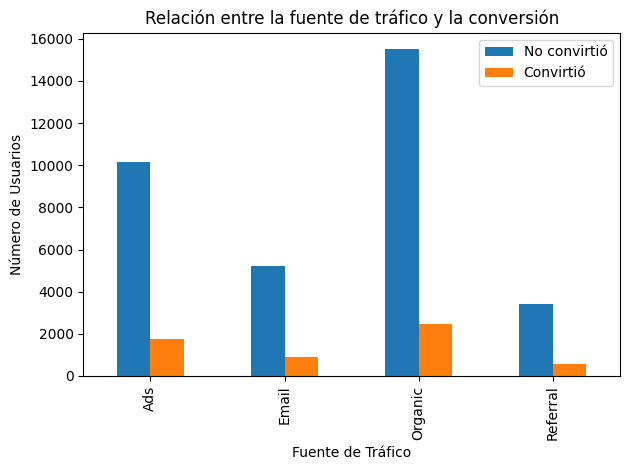

In [23]:
tabla.plot(kind='bar')
plt.title('Relación entre la fuente de tráfico y la conversión')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Número de Usuarios')
plt.tight_layout()
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

✍️ **Comentario para el gráfico "Relación entre la fuente de tráfico y conversión"**: 
Organic y Ads concentran el mayor volumen de usuarios, con 17,987 y 11,935 usuarios respectivamente, siendo los canales con mayor alcance. En términos de conversiones, Organic generó 2,480 y Ads 1,759. Email y Referral muestran menor volumen de tráfico. La prueba chi-cuadrado (p = 0.034) confirma que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión, aunque las diferencias prácticas entre canales son pequeñas.

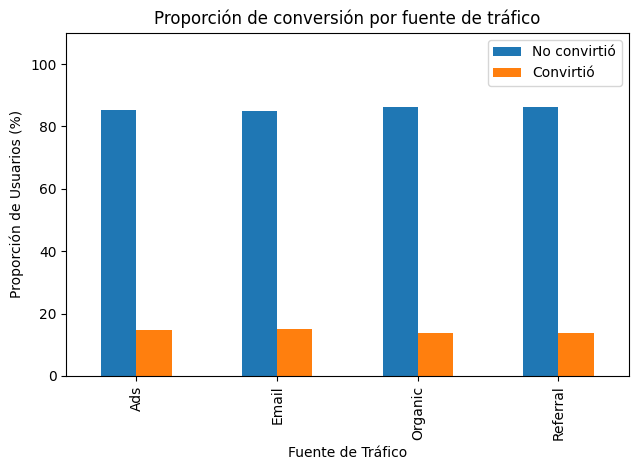

In [24]:
tabla_traffic_norm.plot(kind='bar')
plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Proporción de Usuarios (%)')
plt.tight_layout()
plt.legend(['No convirtió', 'Convirtió'])
plt.ylim(0, 110)
plt.show()

✍️ **Comentario para el gráfico "Proporción de conversión por fuente de tráfico"**: 
Al analizar las proporciones, se observa que todos los canales presentan tasas de conversión similares, oscilando entre el 13.79% de Organic (la más baja) y el 14.99% de Email (la más alta). Aunque las diferencias visuales entre canales son pequeñas, la prueba chi-cuadrado confirmó que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.034).

### User Type vs Conversion

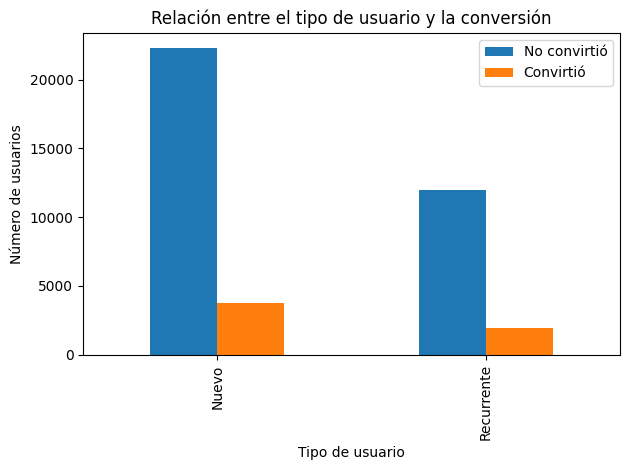

In [29]:
tabla_user.plot(kind='bar')
plt.title('Relación entre el tipo de usuario y la conversión')
plt.xlabel('Tipo de usuario')
plt.ylabel('Número de usuarios')
plt.tight_layout()
plt.legend(['No convirtió', 'Convirtió'])
plt.show()

✍️ **Comentario para el gráfico "Relación entre el tipo de usuario y la conversión"**:
El gráfico muestra que los usuarios Nuevos superan en volumen a los Recurrentes (26,033 vs 13,967). Aunque en términos absolutos los Nuevos generaron más conversiones (3,738 vs 1,968), las tasas de conversión de ambos grupos son prácticamente idénticas: 14.36% para Nuevos y 14.09% para Recurrentes. La prueba chi-cuadrado (p = 0.47) confirma que no existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión, por lo que el comportamiento de compra es similar independientemente de si el usuario es nuevo o recurrente.

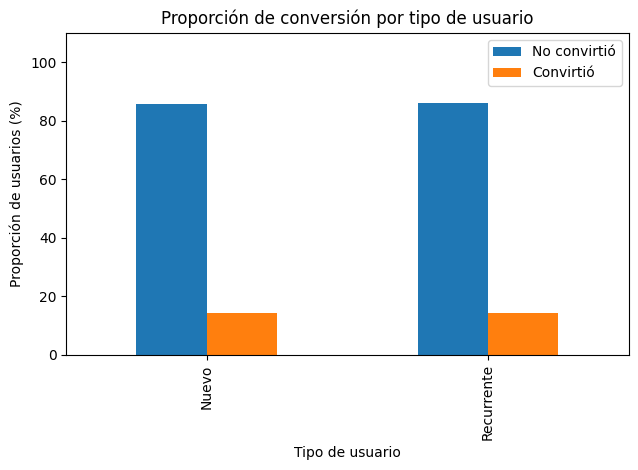

In [32]:
tabla_user_norm.plot(kind='bar')
plt.title("Proporción de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción de usuarios (%)")
plt.tight_layout()
plt.legend(['No convirtió', 'Convirtió'])
plt.ylim(0, 110)
plt.show()

✍️ **Comentario para el gráfico "Proporción de conversión por tipo de usuario"**:
El gráfico muestra que si bien los usuarios Nuevos registraron más conversiones en términos absolutos, esto se explica por su mayor volumen. Al analizar las proporciones, ambos grupos presentan tasas de conversión casi idénticas (Nuevos: 14.36%, Recurrentes: 14.09%), lo que coincide con el resultado de la prueba chi-cuadrado (p = 0.47): el tipo de usuario no determina la probabilidad de conversión.

## 🧩 7. Executive Summary & Business Recommendations

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Los usuarios que convirtieron en la página B gastaron en promedio $68.75, frente a $61.09 de la página A.
- La diferencia de $7.66 entre ambas páginas es estadísticamente significativa (p = 1.04e-21), respaldada por la prueba Mann-Whitney U.
- **Interpretación:**
- La página B no solo atrae conversiones, sino que además genera mayor gasto por usuario, lo que la posiciona como la versión más rentable para el negocio.

<br>

**Tasa de conversión:** 
- La página A registró una tasa de conversión de 12.57%
- La página B registró una tasa de conversión de 15.96%, es decir, 3.39 puntos porcentuales más.
- **Interpretación:**
- La página B convierte significativamente mejor que la A, lo que junto al mayor gasto promedio la consolida como la versión superior en todos los indicadores clave.
---

#### 📊 **Segmentación por fuente de tráfico**
- Organic y Ads concentran el mayor volumen de usuarios (17,987 y 11,935 respectivamente), mientras que Email y Referral muestran menor alcance.
- Las tasas de conversión son similares entre canales, oscilando entre 13.79% (Organic) y 14.99% (Email)
- **Interpretación:**
- Aunque las diferencias son pequeñas, la prueba chi-cuadrado (p = 0.034) confirma que el canal de tráfico sí influye en la conversión. Email es el canal más eficiente en tasa de conversión, mientras que Organic aporta el mayor volumen absoluto de conversiones.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios Nuevos superan en volumen a los Recurrentes (26,033 vs 13,967) y generaron más conversiones absolutas (3,738 vs 1,968). Sin embargo, las tasas de conversión son prácticamente idénticas: 14.36% para Nuevos y 14.09% para Recurrentes
- **Interpretación:**
-  La prueba chi-cuadrado (p = 0.47) confirma que el tipo de usuario no influye en la probabilidad de conversión. El mayor volumen de conversiones en usuarios Nuevos se explica simplemente por su mayor presencia en el dataset, no por un comportamiento de compra diferente.

---

Las visualizaciones utilizadas respaldan consistentemente los resultados estadísticos obtenidos en pasos anteriores. El gráfico de proporciones por fuente de tráfico evidenció tasas similares entre canales, confirmado por la prueba chi-cuadrado (p = 0.034). De igual forma, el gráfico de tipo de usuario mostró barras prácticamente idénticas entre Nuevos y Recurrentes, alineado con un p-value de 0.47 que indica ausencia de asociación significativa. Finalmente, los gráficos de conversión y gasto promedio reforzaron visualmente la superioridad de la página B sobre la A en ambos indicadores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la página B como versión definitiva: dado que supera a la página A tanto en tasa de conversión (15.96% vs 12.57%) como en gasto promedio ($68.75 vs $61.09), migrar todo el tráfico a la página B representa una oportunidad clara de incrementar ingresos sin necesidad de aumentar la inversión en adquisición.
-  Potenciar el canal Email y reevaluar Referral: Email es el canal con la tasa de conversión más alta (14.99%) por lo que invertir en segmentación, personalización y automatización podría maximizar su impacto a bajo costo. Por otro lado, Referral presenta el menor volumen de usuarios (3,955) y la segunda tasa de conversión más baja (13.88%), por lo que conviene evaluar si los recursos invertidos en este canal justifican su rendimiento, o si sería más rentable redirigirlos hacia Email u Organic.
-  Enfocar esfuerzos en volumen, no en segmentación por tipo de usuario: dado que Nuevos y Recurrentes convierten de forma casi idéntica, no es necesario diseñar estrategias diferenciadas por tipo de usuario. Es más rentable enfocarse en aumentar el tráfico general hacia la página B.